In [1]:
#Imports

import os
import random
import re
import time
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import redivis
import tensorflow as tf
from skimage.color import rgb2gray
from skimage.transform import resize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.svm import SVC
from tensorflow.keras import layers, models

SEED = 12345
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

VIEWS = ["axial", "coronal", "sagittal"]


/Users/neel/Documents/GitHub/ACLInjuryDetection/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


> **Note:** This setup script only needs to be **run once**. It loads and downloads all the data into your local folder, which takes approximately **45 minutes** to complete.

```python
from pathlib import Path
import re
import pandas as pd
import redivis

# NOTE: This script loads all the dataset files and only needs to be run once.
# Expect the download process to take around 45 minutes to complete.

labels_dir = Path(".")
out_dir = Path("./StanfordMRNet")

dataset = redivis.organization("AIMI").dataset("mrnet_knee_mri_s:4a2c")

for split in ["train", "valid"]:
    labels_path = labels_dir / f"{split}_acl_labels.csv"
    if not labels_path.exists():
        raise FileNotFoundError(f"Missing {labels_path}")

    labels = pd.read_csv(labels_path)
    id_col = "volumeFilename" if "volumeFilename" in labels.columns else labels.columns[0]

    keep_ids = {
        int(match.group())
        for value in labels[id_col].dropna()
        if (match := re.search(r"\d+", str(value)))
    }

    split_dir = out_dir / split
    split_dir.mkdir(parents=True, exist_ok=True)

    table = dataset.table(split)
    df = table.to_pandas_dataframe()

    for _, row in df.iterrows():
        file_name = str(row["file_name"])
        match = re.search(r"\d+", Path(file_name).stem)

        if not match or int(match.group()) not in keep_ids:
            continue

        file_path = split_dir / file_name
        if not file_path.exists():
            file_path.parent.mkdir(parents=True, exist_ok=True)
            table.file(row["file_id"]).download(str(file_path))

## Data mapping & splitting

Loads per-case ACL labels and applies class balancing (equal Normal/Torn case counts) before defining a single case-level 80% train / 20% test split. Splitting on case ID (not per-view file) guarantees a case's axial/coronal/sagittal volumes always land in the same split, and every downstream split (inner tuning holdout, 10-fold CV) inherits both the balanced ratio and the case-level consistency.

In [2]:
#Mapping

def to_binary_label(raw_label):
    if pd.isna(raw_label):
        return None
    v = int(raw_label)
    return 1 if v == 2 else v

def extract_case_id(value):
    m = re.search(r"\d+", str(value))
    return int(m.group()) if m else None

def infer_columns(df):
    cols = list(df.columns)
    id_candidates = ["volumeFilename", "file_name", "filename", "case", "case_id", "id"]
    lbl_candidates = ["aclDiagnosis", "acl_label", "label", "acl"]

    id_col = next((c for c in id_candidates if c in cols), cols[0])
    label_col = next((c for c in lbl_candidates if c in cols), cols[-1])
    return id_col, label_col

def load_split_label_map(csv_path):
    df = pd.read_csv(csv_path)
    id_col, label_col = infer_columns(df)

    return {
        cid: lbl
        for _, row in df.iterrows()
        if (cid := extract_case_id(row[id_col])) is not None
        if (lbl := to_binary_label(row[label_col])) is not None
    }

def map_paths_to_labels(paths, label_map):
    return [
        (p, label_map[cid])
        for p in paths
        if (cid := extract_case_id(p.stem)) in label_map
    ]

def paths_for_view(view):
    dirs = [Path(f"StanfordMRNet/train/{view}"), Path(f"StanfordMRNet/valid/{view}")]
    return sorted(p for d in dirs for p in d.glob("*.npy"))

def mapped_for_view(view, label_map):
    return map_paths_to_labels(paths_for_view(view), label_map)

def filter_by_case_ids(mapped, case_id_set):
    return [(p, y) for p, y in mapped if extract_case_id(p.stem) in case_id_set]

label_map = {}
label_map.update(load_split_label_map("train_acl_labels.csv"))
label_map.update(load_split_label_map("valid_acl_labels.csv"))
label_names = {0: "Normal", 1: "Torn"}

print(f"Labeled cases (before balancing): {len(label_map)}")

# --- Balance classes at the case level (undersample majority class to match minority class count) ---
cases_by_label = {}
for cid, lbl in label_map.items():
    cases_by_label.setdefault(lbl, []).append(cid)

min_class_count = min(len(ids) for ids in cases_by_label.values())
rng = random.Random(SEED)
balanced_case_ids = []
for lbl, ids in cases_by_label.items():
    balanced_case_ids.extend(rng.sample(sorted(ids), min_class_count))

label_map = {cid: label_map[cid] for cid in balanced_case_ids}
print(f"Balanced pooled dataset: {len(label_map)} cases ({min_class_count} per class)")

# --- ONE case-level 80/20 split, computed once over all pooled cases (train/ and valid/ folders no longer define the split) ---
all_case_ids = sorted(label_map)
case_labels = [label_map[cid] for cid in all_case_ids]

train_case_ids_list, test_case_ids_list = train_test_split(
    all_case_ids, test_size=0.2, stratify=case_labels, random_state=SEED,
)
train_case_ids = set(train_case_ids_list)
test_case_ids = set(test_case_ids_list)

# --- Inner holdout carved from the 80% train pool only, used exclusively for hyperparameter tuning ---
inner_train_ids_list, inner_holdout_ids_list = train_test_split(
    train_case_ids_list, test_size=0.2,
    stratify=[label_map[cid] for cid in train_case_ids_list], random_state=SEED,
)
inner_train_ids = set(inner_train_ids_list)
inner_holdout_ids = set(inner_holdout_ids_list)

# --- Verification ---
def _counts(ids):
    ys = [label_map[i] for i in ids]
    return len(ids), ys.count(0), ys.count(1)

n_all, n_all0, n_all1 = _counts(all_case_ids)
print(f"\nPooled dataset: {n_all} cases (Normal={n_all0}, Torn={n_all1})")

n_tr, n_tr0, n_tr1 = _counts(train_case_ids)
n_te, n_te0, n_te1 = _counts(test_case_ids)
print(f"Outer 80/20 split: train={n_tr} (Normal={n_tr0}, Torn={n_tr1})  test={n_te} (Normal={n_te0}, Torn={n_te1})")

n_itr, n_itr0, n_itr1 = _counts(inner_train_ids)
n_iho, n_iho0, n_iho1 = _counts(inner_holdout_ids)
print(f"Inner tuning split (from train only): inner_train={n_itr} (Normal={n_itr0}, Torn={n_itr1})  "
      f"inner_holdout={n_iho} (Normal={n_iho0}, Torn={n_iho1})")

assert n_all0 == n_all1, "pooled dataset is not class-balanced!"
assert train_case_ids.isdisjoint(test_case_ids), "train/test case overlap!"
assert train_case_ids | test_case_ids == set(all_case_ids), "train/test do not cover all cases!"
assert inner_train_ids.isdisjoint(inner_holdout_ids), "inner train/holdout overlap!"
assert inner_train_ids | inner_holdout_ids == train_case_ids, "inner train/holdout do not cover the 80% train pool!"
assert inner_train_ids.isdisjoint(test_case_ids) and inner_holdout_ids.isdisjoint(test_case_ids), \
    "inner tuning split leaked into the outer test set!"

for view in VIEWS:
    view_case_ids = {extract_case_id(p.stem) for p in paths_for_view(view)} & set(label_map)
    assert view_case_ids == set(all_case_ids), f"{view}: case id set does not match pooled label_map"
print("Verified: axial/coronal/sagittal all cover the identical set of case IDs.")

print("No train/test overlap, full case coverage, class-balanced pool, and inner tuning split fully "
      "contained in the 80% train pool - verified.")


Labeled cases (before balancing): 1248
Balanced pooled dataset: 524 cases (262 per class)

Pooled dataset: 524 cases (Normal=262, Torn=262)
Outer 80/20 split: train=419 (Normal=209, Torn=210)  test=105 (Normal=53, Torn=52)
Inner tuning split (from train only): inner_train=335 (Normal=167, Torn=168)  inner_holdout=84 (Normal=42, Torn=42)
Verified: axial/coronal/sagittal all cover the identical set of case IDs.
No train/test overlap, full case coverage, class-balanced pool, and inner tuning split fully contained in the 80% train pool - verified.


## Preprocessing

Loads each case's center MRI slice, resizes to 64x64, and normalizes to [0,1]. Deliberately minimal: no HOG, segmentation, or other feature engineering — every model sees the MRI's raw visual appearance, not a hand-crafted representation of it.

In [3]:
#Preprocessing (raw MRI appearance only - resize + normalize, no feature engineering, no subsampling)

IMG_SIZE = (64, 64)

def load_center_slice(path):
    volume = np.load(path, allow_pickle=True)
    center_slice = volume[volume.shape[0] // 2] if volume.ndim == 3 else volume
    if center_slice.ndim == 3:
        center_slice = rgb2gray(center_slice)
    return resize(center_slice, IMG_SIZE, anti_aliasing=True).astype(np.float32)

def build_split_arrays(mapped_split):
    images_list, labels_list = [], []
    t0 = time.time()
    for p, y in mapped_split:
        images_list.append(load_center_slice(p))
        labels_list.append(y)

    X_images = np.stack(images_list)
    y_labels = np.array(labels_list)

    print(f"Built {len(y_labels)} samples in {time.time()-t0:.1f}s")
    return X_images, y_labels

import inspect
assert "max_samples" not in inspect.getsource(build_split_arrays).lower(), \
    "build_split_arrays still contains subsampling logic"
print("Verified: no MAX_SAMPLES/subsampling logic in build_split_arrays.")


Verified: no MAX_SAMPLES/subsampling logic in build_split_arrays.


## Models

Three classifiers, compared on identical data and splits: **SVM** (`sklearn.svm.SVC`) and **Logistic Regression**, both trained on flattened raw pixels, and a small **CNN** operating on the 2D image directly.

In [4]:
#Model architecture

def build_svm(C=1.0, kernel="rbf"):
    return SVC(C=C, kernel=kernel, random_state=SEED)

def build_logr(C=1.0, solver="lbfgs"):
    return LogisticRegression(C=C, solver=solver, max_iter=2000, random_state=SEED)

def build_cnn(input_shape, learning_rate=1e-4):
    cnn_model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPool2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPool2D(),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return cnn_model


## Data loading per view

For each view, builds four arrays from the case-ID sets defined above:
- `train` / `test` — the outer 80%/20% split. `test` is touched exactly once, at the very end.
- `inner_train` / `inner_holdout` — a further split carved out of the 80% train pool only, used exclusively for hyperparameter tuning below.

In [5]:
#Data loading per view (pooled train/+valid/, case-level 80% train / 20% test, plus an inner tuning split from the 80% pool)

view_data = {}
for view in VIEWS:
    mapped = mapped_for_view(view, label_map)

    train_mapped = filter_by_case_ids(mapped, train_case_ids)
    test_mapped = filter_by_case_ids(mapped, test_case_ids)
    inner_train_mapped = filter_by_case_ids(mapped, inner_train_ids)
    inner_holdout_mapped = filter_by_case_ids(mapped, inner_holdout_ids)

    X_raw_train, y_train = build_split_arrays(train_mapped)
    X_raw_test, y_test = build_split_arrays(test_mapped)
    X_raw_itr, y_inner_train = build_split_arrays(inner_train_mapped)
    X_raw_iho, y_inner_holdout = build_split_arrays(inner_holdout_mapped)

    X_raw_train = np.clip(X_raw_train, 0.0, 1.0)
    X_raw_test = np.clip(X_raw_test, 0.0, 1.0)
    X_raw_itr = np.clip(X_raw_itr, 0.0, 1.0)
    X_raw_iho = np.clip(X_raw_iho, 0.0, 1.0)

    view_data[view] = dict(
        X_flat_train=X_raw_train.reshape(len(X_raw_train), -1),
        X_images_train=X_raw_train[..., np.newaxis],
        y_train=y_train,
        X_flat_test=X_raw_test.reshape(len(X_raw_test), -1),
        X_images_test=X_raw_test[..., np.newaxis],
        y_test=y_test,
        X_flat_inner_train=X_raw_itr.reshape(len(X_raw_itr), -1),
        X_images_inner_train=X_raw_itr[..., np.newaxis],
        y_inner_train=y_inner_train,
        X_flat_inner_holdout=X_raw_iho.reshape(len(X_raw_iho), -1),
        X_images_inner_holdout=X_raw_iho[..., np.newaxis],
        y_inner_holdout=y_inner_holdout,
    )
    print(f"\n[{view}] train: {dict(Counter(y_train.tolist()))}  test: {dict(Counter(y_test.tolist()))}")


Built 419 samples in 0.9s


Built 105 samples in 0.2s


Built 335 samples in 0.2s
Built 84 samples in 0.1s

[axial] train: {1: 210, 0: 209}  test: {0: 53, 1: 52}


Built 419 samples in 0.8s


Built 105 samples in 0.2s


Built 335 samples in 0.3s
Built 84 samples in 0.1s

[coronal] train: {1: 210, 0: 209}  test: {0: 53, 1: 52}


Built 419 samples in 0.8s


Built 105 samples in 0.2s


Built 335 samples in 0.2s
Built 84 samples in 0.1s

[sagittal] train: {1: 210, 0: 209}  test: {0: 53, 1: 52}


## Hyperparameter tuning

Small grids per model, scored on the inner holdout only — never the outer test set or the CV folds below. This keeps model selection fully separated from both the reported CV metrics and the final test evaluation.

In [6]:
#Hyperparameter tuning (small grids, fit on each view's inner-train pool, score on that view's inner holdout)
#
# Both the inner-train and inner-holdout splits here are carved out of the 80% outer train pool only
# (see the Mapping cell). The 10-fold CV further below evaluates over the FULL 80% train pool, and the
# outer 20% test set is never touched by tuning or CV - only by the single final evaluation at the end.

CNN_GRID = [
    {"learning_rate": lr, "epochs": 8}
    for lr in [1e-4, 5e-4, 1e-3]
]

SVM_GRID = [
    {"C": c, "kernel": k}
    for c in [0.1, 1, 10]
    for k in ["linear", "rbf"]
]

LOGREG_GRID = [
    {"C": c, "solver": s}
    for c in [0.1, 1, 10]
    for s in ["lbfgs", "liblinear"]
]

def tune_svm_or_logreg(build_fn, grid, X_train, y_train, X_val, y_val):
    sweep = []
    for hp in grid:
        model = build_fn(**hp).fit(X_train, y_train)
        val_acc = accuracy_score(y_val, model.predict(X_val))
        sweep.append({**hp, "val_acc": val_acc})
    best = max(sweep, key=lambda r: r["val_acc"])
    return best, sweep

def tune_cnn(grid, X_train, y_train, X_val, y_val, input_shape):
    sweep = []
    for hp in grid:
        model = build_cnn(input_shape, learning_rate=hp["learning_rate"])
        model.fit(X_train, y_train, epochs=hp["epochs"], batch_size=16, verbose=0)
        val_pred = (model.predict(X_val, verbose=0).ravel() >= 0.5).astype(int)
        val_acc = accuracy_score(y_val, val_pred)
        sweep.append({**hp, "val_acc": val_acc})
    best = max(sweep, key=lambda r: r["val_acc"])
    return best, sweep

best_hparams = {}
tuning_sweeps = {}
for view in VIEWS:
    d = view_data[view]

    best_hparams[("svm", view)], tuning_sweeps[("svm", view)] = tune_svm_or_logreg(
        build_svm, SVM_GRID, d["X_flat_inner_train"], d["y_inner_train"],
        d["X_flat_inner_holdout"], d["y_inner_holdout"])
    best_hparams[("logreg", view)], tuning_sweeps[("logreg", view)] = tune_svm_or_logreg(
        build_logr, LOGREG_GRID, d["X_flat_inner_train"], d["y_inner_train"],
        d["X_flat_inner_holdout"], d["y_inner_holdout"])
    best_hparams[("cnn", view)], tuning_sweeps[("cnn", view)] = tune_cnn(
        CNN_GRID, d["X_images_inner_train"], d["y_inner_train"],
        d["X_images_inner_holdout"], d["y_inner_holdout"],
        d["X_images_inner_train"].shape[1:])

    print(f"\n[{view}] best SVM:     {best_hparams[('svm', view)]}")
    print(f"[{view}] best LogReg:   {best_hparams[('logreg', view)]}")
    print(f"[{view}] best CNN:      {best_hparams[('cnn', view)]}")



[axial] best SVM:     {'C': 1, 'kernel': 'linear', 'val_acc': 0.6309523809523809}
[axial] best LogReg:   {'C': 1, 'solver': 'lbfgs', 'val_acc': 0.6190476190476191}
[axial] best CNN:      {'learning_rate': 0.001, 'epochs': 8, 'val_acc': 0.6904761904761905}



[coronal] best SVM:     {'C': 0.1, 'kernel': 'rbf', 'val_acc': 0.5}
[coronal] best LogReg:   {'C': 0.1, 'solver': 'lbfgs', 'val_acc': 0.5476190476190477}
[coronal] best CNN:      {'learning_rate': 0.0001, 'epochs': 8, 'val_acc': 0.5357142857142857}



[sagittal] best SVM:     {'C': 0.1, 'kernel': 'linear', 'val_acc': 0.6666666666666666}
[sagittal] best LogReg:   {'C': 0.1, 'solver': 'liblinear', 'val_acc': 0.6904761904761905}
[sagittal] best CNN:      {'learning_rate': 0.0001, 'epochs': 8, 'val_acc': 0.7023809523809523}


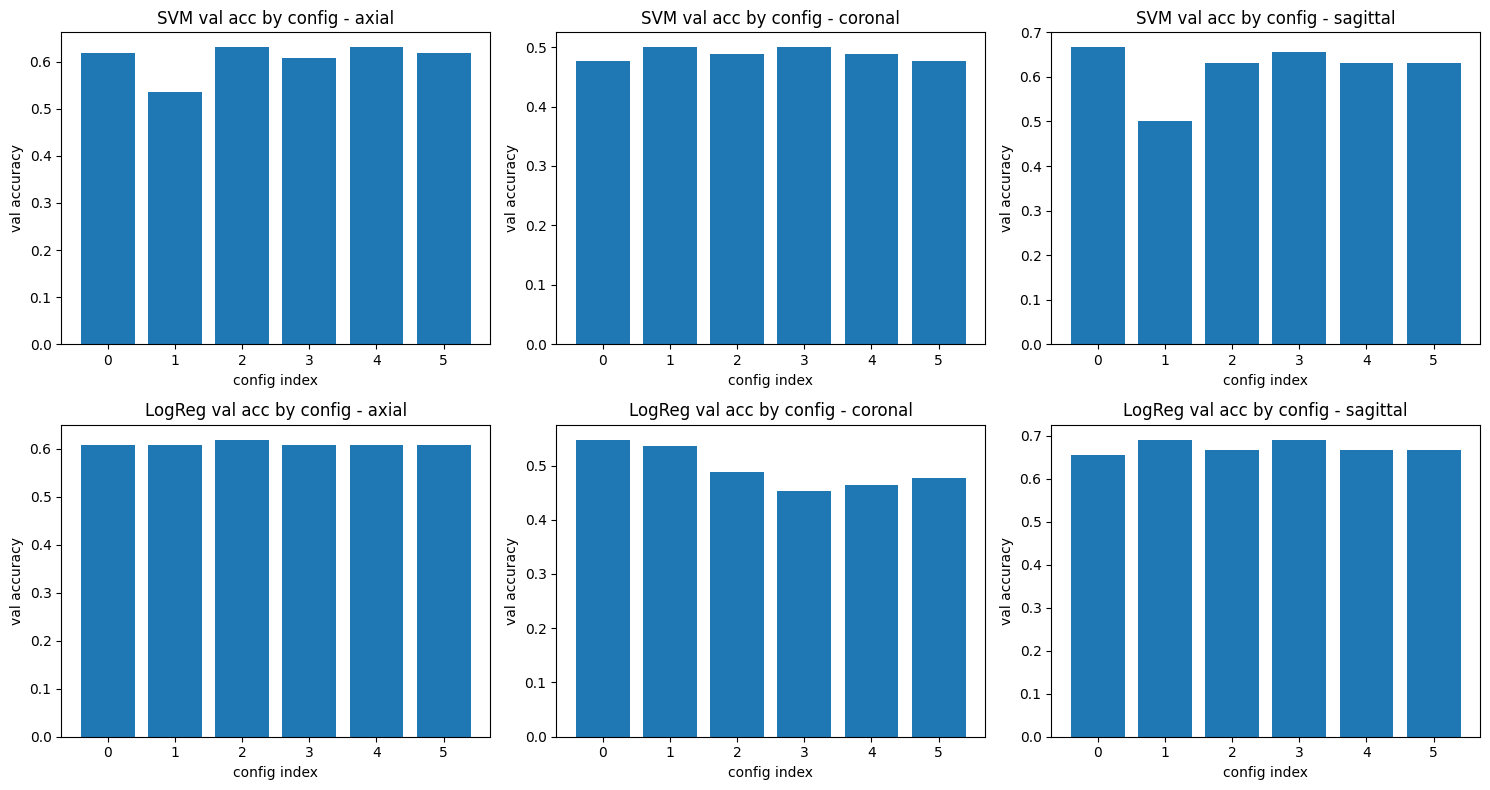

In [7]:
#SVM / LogReg hyperparameter-sweep validation plots (real search results, not fabricated epoch curves)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, view in enumerate(VIEWS):
    svm_sweep = tuning_sweeps[("svm", view)]
    axes[0, col].bar(range(len(svm_sweep)), [r["val_acc"] for r in svm_sweep])
    axes[0, col].set_title(f"SVM val acc by config - {view}")
    axes[0, col].set_xlabel("config index")
    axes[0, col].set_ylabel("val accuracy")

    logreg_sweep = tuning_sweeps[("logreg", view)]
    axes[1, col].bar(range(len(logreg_sweep)), [r["val_acc"] for r in logreg_sweep])
    axes[1, col].set_title(f"LogReg val acc by config - {view}")
    axes[1, col].set_xlabel("config index")
    axes[1, col].set_ylabel("val accuracy")

plt.tight_layout()
plt.show()


## CNN training curves

A one-off fit per view, separate from the 10-fold CV below, purely to show real train/validation loss & accuracy curves — using the same inner holdout as tuning, never the outer test set.

Epoch 1/8


21/21 - 1s - 34ms/step - accuracy: 0.5791 - loss: 0.6774 - val_accuracy: 0.5000 - val_loss: 0.7139


Epoch 2/8


21/21 - 0s - 11ms/step - accuracy: 0.6269 - loss: 0.6264 - val_accuracy: 0.5595 - val_loss: 0.7289


Epoch 3/8


...

21/21 - 0s - 11ms/step - accuracy: 0.7015 - loss: 0.6222 - val_accuracy: 0.6786 - val_loss: 0.6208


Epoch 7/8


21/21 - 0s - 11ms/step - accuracy: 0.6896 - loss: 0.6081 - val_accuracy: 0.6905 - val_loss: 0.6071


Epoch 8/8


21/21 - 0s - 11ms/step - accuracy: 0.6866 - loss: 0.5909 - val_accuracy: 0.6786 - val_loss: 0.6048


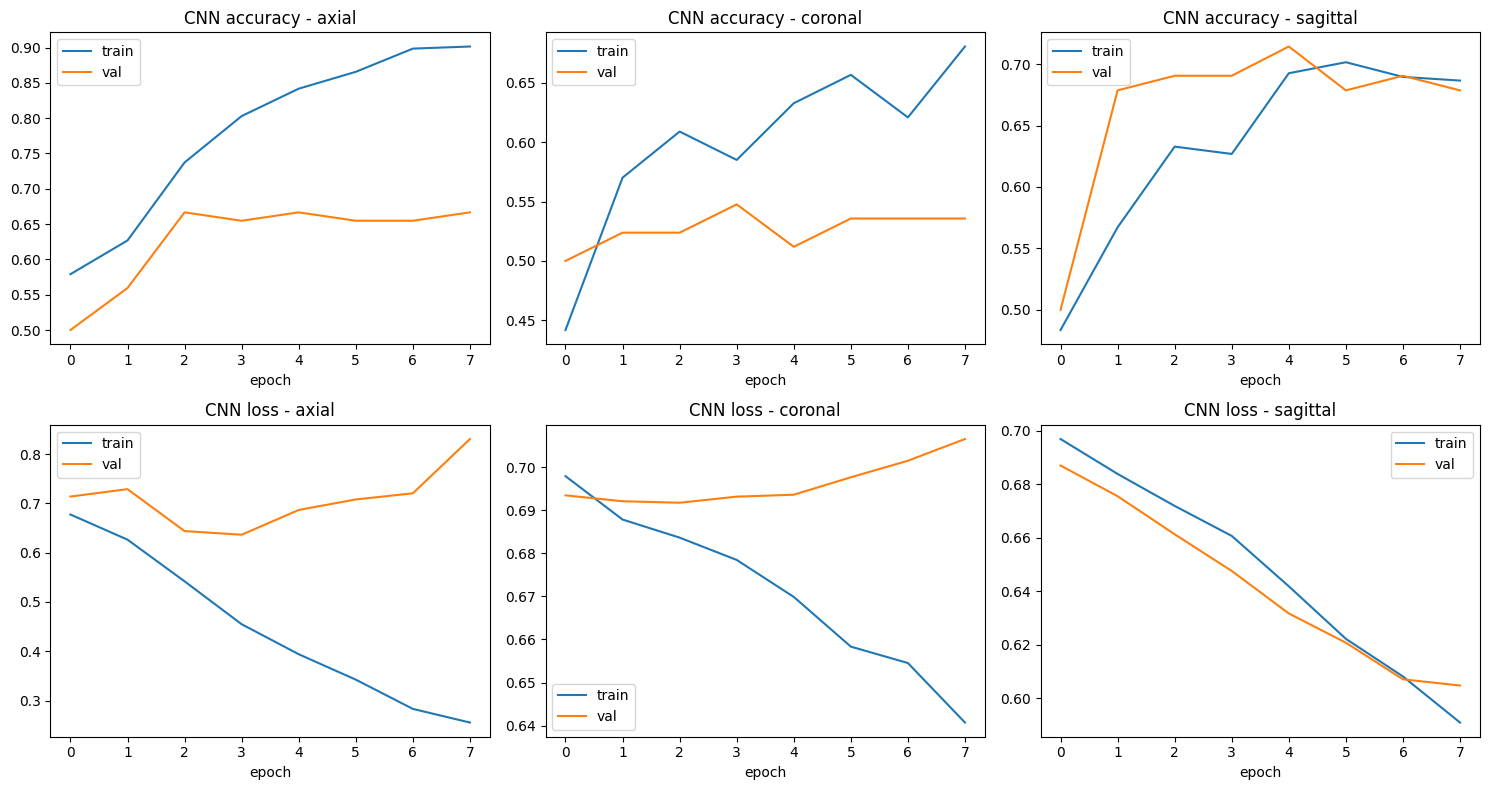

In [8]:
#CNN training curves (tuned hyperparameters, per view)
# This refit is separate from the 10-fold CV below - it exists purely to produce real
# train/val loss & accuracy curves from an actual .fit() call using the already-selected winning hyperparameters,
# validated against the same inner holdout used for tuning (never the outer 20% test set).

cnn_histories = {}
for view in VIEWS:
    d = view_data[view]
    hp = best_hparams[("cnn", view)]

    model = build_cnn(d["X_images_inner_train"].shape[1:], learning_rate=hp["learning_rate"])
    hist = model.fit(
        d["X_images_inner_train"], d["y_inner_train"],
        epochs=hp["epochs"], batch_size=16,
        validation_data=(d["X_images_inner_holdout"], d["y_inner_holdout"]),
        verbose=2,
    )
    cnn_histories[view] = hist.history

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, view in enumerate(VIEWS):
    h = cnn_histories[view]
    axes[0, col].plot(h["accuracy"], label="train")
    axes[0, col].plot(h["val_accuracy"], label="val")
    axes[0, col].set_title(f"CNN accuracy - {view}")
    axes[0, col].set_xlabel("epoch")
    axes[0, col].legend()

    axes[1, col].plot(h["loss"], label="train")
    axes[1, col].plot(h["val_loss"], label="val")
    axes[1, col].set_title(f"CNN loss - {view}")
    axes[1, col].set_xlabel("epoch")
    axes[1, col].legend()

plt.tight_layout()
plt.savefig("image_multiview_cnn_curves.png")
plt.show()


## Final 10-fold CV + held-out test evaluation

Runs the required 10-fold CV over the entire 80% train pool, using one shared fold split reused identically for every model/view (a fair, apples-to-apples comparison). Each model is then refit on the full 80% pool and evaluated exactly once on the untouched 20% test set — the only place the test set is used anywhere in this notebook.

In [9]:
#Final 10-fold CV (over the full 80% train pool, all 9 combos) + save optimized models + ONE final evaluation on the untouched 20% test set

N_SPLITS = 10
results = []
Path("optimized_models").mkdir(exist_ok=True)

# Shared fold split, computed once: valid across every view and every model, since y_train is
# identical in content and order across views (all views are filtered by the same train_case_ids,
# in the same sorted order - verified in the Mapping cell).
kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
shared_fold_indices = list(kfold.split(view_data["axial"]["X_flat_train"], view_data["axial"]["y_train"]))

for view in VIEWS:
    assert np.array_equal(view_data[view]["y_train"], view_data["axial"]["y_train"]), \
        f"{view}: y_train differs from axial - shared fold indices would be invalid"

val_counts = np.zeros(len(view_data["axial"]["y_train"]), dtype=int)
for _, val_idx in shared_fold_indices:
    val_counts[val_idx] += 1
assert (val_counts == 1).all(), "some training cases are in 0 or >1 validation folds"

print(f"Shared {N_SPLITS}-fold split (reused identically across all views/models):")
y_ref = view_data["axial"]["y_train"]
for fold_idx, (train_idx, val_idx) in enumerate(shared_fold_indices, start=1):
    y_tr, y_va = y_ref[train_idx], y_ref[val_idx]
    print(f"  Fold {fold_idx}: train={len(train_idx)} (Normal={(y_tr==0).sum()}, Torn={(y_tr==1).sum()})  "
          f"val={len(val_idx)} (Normal={(y_va==0).sum()}, Torn={(y_va==1).sum()})")
print("Verified: every training case appears in exactly one validation fold; folds identical across views.\n")

def run_kfold(view, model_key, build_fn, hp, X, y, fold_indices, is_cnn=False):
    fold_accs = []
    oof_true = np.empty_like(y)
    oof_pred = np.empty_like(y)
    labels_sorted = sorted(np.unique(y))
    target_names = [label_names[i] for i in labels_sorted]

    for fold_idx, (train_idx, val_idx) in enumerate(fold_indices, start=1):
        y_tr, y_va = y[train_idx], y[val_idx]

        if is_cnn:
            model = build_fn(X.shape[1:], learning_rate=hp["learning_rate"])
            model.fit(X[train_idx], y_tr, epochs=hp["epochs"], batch_size=16, verbose=0)
            pred = (model.predict(X[val_idx], verbose=0).ravel() >= 0.5).astype(int)
        else:
            model = build_fn(**hp).fit(X[train_idx], y_tr)
            pred = model.predict(X[val_idx])

        fold_accs.append(accuracy_score(y_va, pred))
        oof_true[val_idx] = y_va
        oof_pred[val_idx] = pred

        print(f"\n===== {model_key} / {view} - Fold {fold_idx}/{N_SPLITS} =====")
        print(classification_report(y_va, pred, labels=labels_sorted, target_names=target_names))
        print(f"Confusion matrix (rows=true, cols=pred):\n{confusion_matrix(y_va, pred, labels=labels_sorted)}")

    print(f"\n{model_key} / {view} - out-of-fold classification report ({N_SPLITS} folds combined):")
    print(classification_report(oof_true, oof_pred, labels=labels_sorted, target_names=target_names))
    print(f"Confusion matrix (rows=true, cols=pred):\n{confusion_matrix(oof_true, oof_pred, labels=labels_sorted)}")

    return fold_accs, oof_true, oof_pred

for view in VIEWS:
    d = view_data[view]
    labels_sorted = sorted(np.unique(d["y_train"]))
    target_names = [label_names[i] for i in labels_sorted]

    for model_key, build_fn, feature_key, test_key in [
        ("svm", build_svm, "X_flat_train", "X_flat_test"),
        ("logreg", build_logr, "X_flat_train", "X_flat_test"),
    ]:
        hp = {k: v for k, v in best_hparams[(model_key, view)].items() if k != "val_acc"}
        fold_accs, oof_true, oof_pred = run_kfold(
            view, model_key, build_fn, hp, d[feature_key], d["y_train"], shared_fold_indices)
        cv_prec, cv_rec, cv_f1, _ = precision_recall_fscore_support(oof_true, oof_pred, average="macro")
        cv_acc = accuracy_score(oof_true, oof_pred)

        final_model = build_fn(**hp).fit(d[feature_key], d["y_train"])
        joblib.dump(final_model, f"optimized_models/{model_key}_{view}.joblib")

        test_pred = final_model.predict(d[test_key])
        test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(d["y_test"], test_pred, average="macro")
        test_acc = accuracy_score(d["y_test"], test_pred)
        print(f"\n===== {model_key} / {view} - FINAL TEST SET (untouched 20%, evaluated once) =====")
        print(classification_report(d["y_test"], test_pred, labels=labels_sorted, target_names=target_names))
        print(f"Confusion matrix (rows=true, cols=pred):\n{confusion_matrix(d['y_test'], test_pred, labels=labels_sorted)}")

        results.append(dict(
            model=model_key, view=view, hyperparameters=hp,
            cv_accuracy=cv_acc, cv_precision=cv_prec, cv_recall=cv_rec, cv_f1=cv_f1, cv_fold_accuracies=fold_accs,
            test_accuracy=test_acc, test_precision=test_prec, test_recall=test_rec, test_f1=test_f1,
        ))

    hp = {k: v for k, v in best_hparams[("cnn", view)].items() if k != "val_acc"}
    fold_accs, oof_true, oof_pred = run_kfold(
        view, "cnn", build_cnn, hp, d["X_images_train"], d["y_train"], shared_fold_indices, is_cnn=True)
    cv_prec, cv_rec, cv_f1, _ = precision_recall_fscore_support(oof_true, oof_pred, average="macro")
    cv_acc = accuracy_score(oof_true, oof_pred)

    final_cnn = build_cnn(d["X_images_train"].shape[1:], learning_rate=hp["learning_rate"])
    final_cnn.fit(d["X_images_train"], d["y_train"], epochs=hp["epochs"], batch_size=16, verbose=0)
    final_cnn.save(f"optimized_models/cnn_{view}.keras")

    test_pred = (final_cnn.predict(d["X_images_test"], verbose=0).ravel() >= 0.5).astype(int)
    test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(d["y_test"], test_pred, average="macro")
    test_acc = accuracy_score(d["y_test"], test_pred)
    print(f"\n===== cnn / {view} - FINAL TEST SET (untouched 20%, evaluated once) =====")
    print(classification_report(d["y_test"], test_pred, labels=labels_sorted, target_names=target_names))
    print(f"Confusion matrix (rows=true, cols=pred):\n{confusion_matrix(d['y_test'], test_pred, labels=labels_sorted)}")

    results.append(dict(
        model="cnn", view=view, hyperparameters=hp,
        cv_accuracy=cv_acc, cv_precision=cv_prec, cv_recall=cv_rec, cv_f1=cv_f1, cv_fold_accuracies=fold_accs,
        test_accuracy=test_acc, test_precision=test_prec, test_recall=test_rec, test_f1=test_f1,
    ))

results_df = pd.DataFrame(results)

assert "class_weight" not in inspect.getsource(build_cnn), "build_cnn/training should not perform class balancing"
print("\nVerified: no class_weight/class-balancing used anywhere in CNN training.")


Shared 10-fold split (reused identically across all views/models):
  Fold 1: train=377 (Normal=188, Torn=189)  val=42 (Normal=21, Torn=21)
  Fold 2: train=377 (Normal=188, Torn=189)  val=42 (Normal=21, Torn=21)
  Fold 3: train=377 (Normal=188, Torn=189)  val=42 (Normal=21, Torn=21)
  Fold 4: train=377 (Normal=188, Torn=189)  val=42 (Normal=21, Torn=21)
  Fold 5: train=377 (Normal=188, Torn=189)  val=42 (Normal=21, Torn=21)
  Fold 6: train=377 (Normal=188, Torn=189)  val=42 (Normal=21, Torn=21)
  Fold 7: train=377 (Normal=188, Torn=189)  val=42 (Normal=21, Torn=21)
  Fold 8: train=377 (Normal=188, Torn=189)  val=42 (Normal=21, Torn=21)
  Fold 9: train=377 (Normal=188, Torn=189)  val=42 (Normal=21, Torn=21)
  Fold 10: train=378 (Normal=189, Torn=189)  val=41 (Normal=20, Torn=21)
Verified: every training case appears in exactly one validation fold; folds identical across views.


===== svm / axial - Fold 1/10 =====
              precision    recall  f1-score   support

      Normal       


===== svm / axial - Fold 6/10 =====
              precision    recall  f1-score   support

      Normal       0.71      0.71      0.71        21
        Torn       0.71      0.71      0.71        21

    accuracy                           0.71        42
   macro avg       0.71      0.71      0.71        42
weighted avg       0.71      0.71      0.71        42

Confusion matrix (rows=true, cols=pred):
[[15  6]
 [ 6 15]]

===== svm / axial - Fold 7/10 =====
              precision    recall  f1-score   support

      Normal       0.60      0.57      0.59        21
        Torn       0.59      0.62      0.60        21

    accuracy                           0.60        42
   macro avg       0.60      0.60      0.60        42
weighted avg       0.60      0.60      0.60        42

Confusion matrix (rows=true, cols=pred):
[[12  9]
 [ 8 13]]

===== svm / axial - Fold 8/10 =====
              precision    recall  f1-score   support

      Normal       0.64      0.67      0.65        21
      


===== svm / axial - FINAL TEST SET (untouched 20%, evaluated once) =====
              precision    recall  f1-score   support

      Normal       0.61      0.62      0.62        53
        Torn       0.61      0.60      0.60        52

    accuracy                           0.61       105
   macro avg       0.61      0.61      0.61       105
weighted avg       0.61      0.61      0.61       105

Confusion matrix (rows=true, cols=pred):
[[33 20]
 [21 31]]

===== logreg / axial - Fold 1/10 =====
              precision    recall  f1-score   support

      Normal       0.65      0.52      0.58        21
        Torn       0.60      0.71      0.65        21

    accuracy                           0.62        42
   macro avg       0.62      0.62      0.62        42
weighted avg       0.62      0.62      0.62        42

Confusion matrix (rows=true, cols=pred):
[[11 10]
 [ 6 15]]

===== logreg / axial - Fold 2/10 =====
              precision    recall  f1-score   support

      Normal     


===== logreg / axial - Fold 6/10 =====
              precision    recall  f1-score   support

      Normal       0.74      0.81      0.77        21
        Torn       0.79      0.71      0.75        21

    accuracy                           0.76        42
   macro avg       0.76      0.76      0.76        42
weighted avg       0.76      0.76      0.76        42

Confusion matrix (rows=true, cols=pred):
[[17  4]
 [ 6 15]]

===== logreg / axial - Fold 7/10 =====
              precision    recall  f1-score   support

      Normal       0.62      0.62      0.62        21
        Torn       0.62      0.62      0.62        21

    accuracy                           0.62        42
   macro avg       0.62      0.62      0.62        42
weighted avg       0.62      0.62      0.62        42

Confusion matrix (rows=true, cols=pred):
[[13  8]
 [ 8 13]]

===== logreg / axial - Fold 8/10 =====
              precision    recall  f1-score   support

      Normal       0.68      0.71      0.70        


===== logreg / axial - FINAL TEST SET (untouched 20%, evaluated once) =====
              precision    recall  f1-score   support

      Normal       0.63      0.64      0.64        53
        Torn       0.63      0.62      0.62        52

    accuracy                           0.63       105
   macro avg       0.63      0.63      0.63       105
weighted avg       0.63      0.63      0.63       105

Confusion matrix (rows=true, cols=pred):
[[34 19]
 [20 32]]


...


===== cnn / sagittal - Fold 7/10 =====
              precision    recall  f1-score   support

      Normal       0.71      0.81      0.76        21
        Torn       0.78      0.67      0.72        21

    accuracy                           0.74        42
   macro avg       0.74      0.74      0.74        42
weighted avg       0.74      0.74      0.74        42

Confusion matrix (rows=true, cols=pred):
[[17  4]
 [ 7 14]]



===== cnn / sagittal - Fold 8/10 =====
              precision    recall  f1-score   support

      Normal       0.58      0.52      0.55        21
        Torn       0.57      0.62      0.59        21

    accuracy                           0.57        42
   macro avg       0.57      0.57      0.57        42
weighted avg       0.57      0.57      0.57        42

Confusion matrix (rows=true, cols=pred):
[[11 10]
 [ 8 13]]



===== cnn / sagittal - Fold 9/10 =====
              precision    recall  f1-score   support

      Normal       0.80      0.57      0.67        21
        Torn       0.67      0.86      0.75        21

    accuracy                           0.71        42
   macro avg       0.73      0.71      0.71        42
weighted avg       0.73      0.71      0.71        42

Confusion matrix (rows=true, cols=pred):
[[12  9]
 [ 3 18]]



===== cnn / sagittal - Fold 10/10 =====
              precision    recall  f1-score   support

      Normal       0.68      0.75      0.71        20
        Torn       0.74      0.67      0.70        21

    accuracy                           0.71        41
   macro avg       0.71      0.71      0.71        41
weighted avg       0.71      0.71      0.71        41

Confusion matrix (rows=true, cols=pred):
[[15  5]
 [ 7 14]]

cnn / sagittal - out-of-fold classification report (10 folds combined):
              precision    recall  f1-score   support

      Normal       0.70      0.66      0.68       209
        Torn       0.68      0.72      0.70       210

    accuracy                           0.69       419
   macro avg       0.69      0.69      0.69       419
weighted avg       0.69      0.69      0.69       419

Confusion matrix (rows=true, cols=pred):
[[137  72]
 [ 58 152]]



===== cnn / sagittal - FINAL TEST SET (untouched 20%, evaluated once) =====
              precision    recall  f1-score   support

      Normal       0.69      0.55      0.61        53
        Torn       0.62      0.75      0.68        52

    accuracy                           0.65       105
   macro avg       0.65      0.65      0.64       105
weighted avg       0.66      0.65      0.64       105

Confusion matrix (rows=true, cols=pred):
[[29 24]
 [13 39]]

Verified: no class_weight/class-balancing used anywhere in CNN training.


## Final summary

Builds the 9-row results table and headline findings (best combo/model/view, CV-vs-test gap) directly from `results_df` — nothing here is hand-typed.

In [10]:
#Final summary + analysis (all derived from results_df, nothing hand-typed)

summary_table = results_df[[
    "model", "view", "hyperparameters",
    "cv_accuracy", "cv_precision", "cv_recall", "cv_f1",
    "test_accuracy", "test_precision", "test_recall", "test_f1",
]]
print(summary_table.to_string(index=False))

best_cv_row = results_df.loc[results_df["cv_f1"].idxmax()]
best_test_row = results_df.loc[results_df["test_f1"].idxmax()]
best_model_overall = results_df.groupby("model")["test_accuracy"].mean().idxmax()
best_view_overall = results_df.groupby("view")["test_accuracy"].mean().idxmax()
instability = results_df.assign(fold_std=results_df["cv_fold_accuracies"].apply(np.std)).sort_values(
    "fold_std", ascending=False)
most_unstable = instability.iloc[0]

print(f"\nBest combo by CV F1: {best_cv_row['model']} / {best_cv_row['view']} "
      f"(cv_accuracy={best_cv_row['cv_accuracy']:.3f}, cv_f1={best_cv_row['cv_f1']:.3f})")
print(f"Best combo by TEST F1 (untouched 20%): {best_test_row['model']} / {best_test_row['view']} "
      f"(test_accuracy={best_test_row['test_accuracy']:.3f}, test_f1={best_test_row['test_f1']:.3f})")
print(f"Best model by mean test accuracy across views: {best_model_overall}")
print(f"Best view by mean test accuracy across models: {best_view_overall}")
print(f"Highest fold-to-fold variance in CV (least stable): {most_unstable['model']} / {most_unstable['view']} "
      f"(fold accuracy std={most_unstable['fold_std']:.3f})")

print("\nMean test accuracy by model:")
print(results_df.groupby("model")["test_accuracy"].mean().to_string())
print("\nMean test accuracy by view:")
print(results_df.groupby("view")["test_accuracy"].mean().to_string())

print("\nCV vs. test accuracy gap per combo (large gap may indicate overfitting to the train pool):")
gap_table = results_df.assign(gap=(results_df["cv_accuracy"] - results_df["test_accuracy"]).abs())[
    ["model", "view", "cv_accuracy", "test_accuracy", "gap"]
].sort_values("gap", ascending=False)
print(gap_table.to_string(index=False))


 model     view                        hyperparameters  cv_accuracy  cv_precision  cv_recall    cv_f1  test_accuracy  test_precision  test_recall  test_f1
   svm    axial           {'C': 1, 'kernel': 'linear'}     0.637232      0.637358   0.637264 0.637180       0.609524        0.609477     0.609398 0.609382
logreg    axial            {'C': 1, 'solver': 'lbfgs'}     0.665871      0.666127   0.665915 0.665778       0.628571        0.628540     0.628447 0.628437
   cnn    axial  {'learning_rate': 0.001, 'epochs': 8}     0.706444      0.708558   0.706562 0.705774       0.657143        0.660581     0.656386 0.654605
   svm  coronal            {'C': 0.1, 'kernel': 'rbf'}     0.510740      0.565602   0.509638 0.377234       0.495238        0.247619     0.500000 0.331210
logreg  coronal          {'C': 0.1, 'solver': 'lbfgs'}     0.556086      0.556688   0.556197 0.555171       0.580952        0.581633     0.581277 0.580610
   cnn  coronal {'learning_rate': 0.0001, 'epochs': 8}     0.594272   

## Verification: reload saved models from disk

Sanity check that the artifacts in `optimized_models/` are exactly what was reported above: reload each of the 9 saved models from disk (not the in-memory objects from the CV cell) and re-run them on the untouched 20% test set, confirming the reloaded predictions reproduce the same `test_accuracy`/`test_precision`/`test_recall`/`test_f1` already in `results_df`.

In [13]:
#Verification - reload the 9 saved models from optimized_models/ and confirm they reproduce the reported test results

verification_rows = []
for view in VIEWS:
    d = view_data[view]

    for model_key, test_key in [("svm", "X_flat_test"), ("logreg", "X_flat_test")]:
        loaded_model = joblib.load(f"optimized_models/{model_key}_{view}.joblib")
        test_pred = loaded_model.predict(d[test_key])
        acc = accuracy_score(d["y_test"], test_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(d["y_test"], test_pred, average="macro")
        verification_rows.append(dict(
            model=model_key, view=view, reloaded_test_accuracy=acc,
            reloaded_test_precision=prec, reloaded_test_recall=rec, reloaded_test_f1=f1,
        ))

    loaded_cnn = tf.keras.models.load_model(f"optimized_models/cnn_{view}.keras")
    test_pred = (loaded_cnn.predict(d["X_images_test"], verbose=0).ravel() >= 0.5).astype(int)
    acc = accuracy_score(d["y_test"], test_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(d["y_test"], test_pred, average="macro")
    verification_rows.append(dict(
        model="cnn", view=view, reloaded_test_accuracy=acc,
        reloaded_test_precision=prec, reloaded_test_recall=rec, reloaded_test_f1=f1,
    ))

verification_df = pd.DataFrame(verification_rows)

comparison = results_df[["model", "view", "test_accuracy", "test_precision", "test_recall", "test_f1"]].merge(
    verification_df, on=["model", "view"]
)
comparison["accuracy_matches"] = np.isclose(comparison["test_accuracy"], comparison["reloaded_test_accuracy"])
print(comparison.to_string(index=False))

assert comparison["accuracy_matches"].all(), \
    "A reloaded model's test accuracy does not match the originally reported result!"
print("\nVerified: every reloaded model reproduces the exact test-set results reported above.")


 model     view  test_accuracy  test_precision  test_recall  test_f1  reloaded_test_accuracy  reloaded_test_precision  reloaded_test_recall  reloaded_test_f1  accuracy_matches
   svm    axial       0.609524        0.609477     0.609398 0.609382                0.609524                 0.609477              0.609398          0.609382              True
logreg    axial       0.628571        0.628540     0.628447 0.628437                0.628571                 0.628540              0.628447          0.628437              True
   cnn    axial       0.657143        0.660581     0.656386 0.654605                0.657143                 0.660581              0.656386          0.654605              True
   svm  coronal       0.495238        0.247619     0.500000 0.331210                0.495238                 0.247619              0.500000          0.331210              True
logreg  coronal       0.580952        0.581633     0.581277 0.580610                0.580952                 0.581633   